# 🏝️ Asistente Turístico de Tenerife — Entrega Final LLM
### Máster en IA, Cloud & DevOps — pontIA.tech  
### Autor: Alexander De Sousa  
### Asignatura: Large Language Models  


Este notebook implementa un asistente turístico basado en:

- Recuperación aumentada (RAG)
- Memoria conversacional multiturno
- Llamadas a herramientas externas (function calling)
- Modelo comercial OpenAI
- Evaluación y análisis crítico

El objetivo es demostrar un pipeline reproducible, modular y evaluable.


Importaciones y configuración

In [1]:
import os
from src.assistant import TenerifeAssistant
from src.rag import build_rag_pipeline, retrieve
from src.memory import ConversationMemory
from src.tools import get_weather
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np

PDF_PATH = "data/TENERIFE.pdf"


Construcción del pipeline RAG

In [2]:
rag = build_rag_pipeline(PDF_PATH)

print("Chunks:", len(rag["chunks"]))
print("Embeddings shape:", rag["embeddings"].shape)
print("Ejemplo de metadata:", rag["metadata"][0])


2026-06-11 14:16:39,048 - src.rag - INFO - Iniciando pipeline RAG para: data/TENERIFE.pdf
2026-06-11 14:16:39,050 - src.rag - INFO - Cargando PDF desde: data/TENERIFE.pdf
2026-06-11 14:16:39,676 - src.rag - INFO - PDF cargado: 25 páginas
2026-06-11 14:16:39,677 - src.rag - INFO - Segmentando texto: chunk_size=800, overlap=150
2026-06-11 14:16:39,679 - src.rag - INFO - Texto segmentado en 35 chunks con metadatos
2026-06-11 14:16:39,735 - src.rag - INFO - Generando embeddings para 35 chunks...
2026-06-11 14:16:41,833 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:16:41,899 - src.rag - INFO - Embeddings generados: forma (35, 1536)
2026-06-11 14:16:41,900 - src.rag - INFO - Construyendo índice FAISS...
2026-06-11 14:16:41,901 - src.rag - INFO - Índice FAISS creado con 35 vectores
2026-06-11 14:16:41,902 - src.rag - INFO - Pipeline RAG completado exitosamente


Chunks: 35
Embeddings shape: (35, 1536)
Ejemplo de metadata: {'page': 1, 'source': 'Guía turística (pág. 1)'}


Ejemplo de chunking

In [3]:
for i in range(3):
    print(f"Chunk {i}:")
    print(rag["chunks"][i][:300], "...\n")


Chunk 0:
TENERIFE – LUGARES DE INTERÉS 
SITIOS QUE VER 
 
ZONA NORTE 
 
• Santa Cruz de Tenerife: 
Santa Cruz de Tenerife es la capital de la isla. Quizás la ruta a seguir si vais a Santa 
Cruz sería: 
- Aparcar en el aparcamiento del Parque Marítimo (ubicación). 
- Caminar por la Avenida Marítima hasta Plaz ...

Chunk 1:
- Volver de nuevo a por el coche. 
- Ir hacia la playa de Las Teresitas (ubicación). 
Los puntos de interés sugeridos son estos: 
o Parque Marítimo César Manrique [vídeo - ubicación] 
Conjunto de piscinas naturales. ...

Chunk 2:
o Auditorio de Tenerife [vídeo - ubicación] 
 
 
o Plaza de España [vídeo - ubicación] ...



Ejemplo de recuperación semántica

In [4]:
query = "Qué puedo ver en el Teide"
results = retrieve(query, rag["chunks"], rag["index"], rag["metadata"], k=3)

for r in results:
    print(f"[{r['index']}] pág {r['page']} → {r['chunk'][:200]}...\n")


2026-06-11 14:16:56,307 - src.rag - INFO - Buscando 3 chunks relevantes para: 'Qué puedo ver en el Teide...'
2026-06-11 14:16:56,509 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:16:56,512 - src.rag - INFO - Encontrados 3 resultados relevantes


[19] pág 15 → • El Teide 
Si vais a Tenerife y no subís al Parque Nacional del Teide, simplemente no habéis 
estado en Tenerife. 
 
Mi recomendación – esto es simplemente gustos personales míos – para subir al 
Tei...

[20] pág 15 → nubes también es espectacular verlo desde el Mirador de Chipeque). 
 
Lo suyo al subir al Teide es llegar hasta el Parador de las Cañadas del Teide y aparcar 
por aquí para ir al mirador de La Ruleta ...

[21] pág 16 → Si queréis subir hasta el pico del Teide, podéis hacerlo desde aquí haciendo uso de 
los teleféricos del Teide. Y, si queréis más info sobre el Teide, podéis ir al Centro de 
Visitantes de El Portillo...



Construcción del asistente

In [5]:
assistant = TenerifeAssistant(PDF_PATH)


2026-06-11 14:17:00,736 - TenerifeAssistant - INFO - Cargando pipeline RAG desde data/TENERIFE.pdf
2026-06-11 14:17:00,737 - src.rag - INFO - Iniciando pipeline RAG para: data/TENERIFE.pdf
2026-06-11 14:17:00,738 - src.rag - INFO - Cargando PDF desde: data/TENERIFE.pdf


DEBUG MODEL: gpt-4.1-mini


2026-06-11 14:17:01,357 - src.rag - INFO - PDF cargado: 25 páginas
2026-06-11 14:17:01,359 - src.rag - INFO - Segmentando texto: chunk_size=800, overlap=150
2026-06-11 14:17:01,360 - src.rag - INFO - Texto segmentado en 35 chunks con metadatos
2026-06-11 14:17:01,361 - src.rag - INFO - Generando embeddings para 35 chunks...
2026-06-11 14:17:02,739 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:17:02,870 - src.rag - INFO - Embeddings generados: forma (35, 1536)
2026-06-11 14:17:02,872 - src.rag - INFO - Construyendo índice FAISS...
2026-06-11 14:17:02,873 - src.rag - INFO - Índice FAISS creado con 35 vectores
2026-06-11 14:17:02,874 - src.rag - INFO - Pipeline RAG completado exitosamente
2026-06-11 14:17:02,875 - src.memory - INFO - ConversationMemory inicializada: max_tokens=2500, model=gpt-4.1-mini
2026-06-11 14:17:02,875 - TenerifeAssistant - INFO - TenerifeAssistant listo para responder preguntas.


Ejemplos de conversación RAG

In [6]:
assistant.answer("Háblame del Teide")


2026-06-11 14:17:07,573 - TenerifeAssistant - INFO - Consulta recibida: 'Háblame del Teide'
2026-06-11 14:17:07,574 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Háblame del Teide...'
2026-06-11 14:17:07,726 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:17:07,729 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-11 14:17:14,297 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:17:14,310 - TenerifeAssistant - INFO - Respuesta generada en 6.74s


'El Teide es una visita imprescindible si vais a Tenerife. Se trata del pico más alto de España, con 3.718 metros, y gran parte del Parque Nacional del Teide pertenece a La Orotava, el municipio más alto de España y con mayor desnivel, ya que va desde el mar hasta el pico [2].\n\nPara subir al Teide, una recomendación personal es hacerlo por la carretera TF24 desde la rotonda de Padre Anchieta en La Laguna. En esa ruta, un lugar digno de parar es el Mirador de La Tarta, conocido así porque la curva tiene piedras de diferentes colores que parecen una tarta. Desde este mirador, si hay nubes en el Norte, se puede ver un espectacular mar de nubes (similar al que se ve desde el Mirador de Chipeque) [1].\n\nAl llegar al Parador de las Cañadas del Teide, se puede aparcar y visitar el mirador de La Ruleta, desde donde se aprecia la estampa más famosa de la isla [4]. \n\nAdemás, si se desea, se puede subir hasta el pico usando los teleféricos del Teide. También hay un Centro de Visitantes en El

In [7]:
assistant.answer("Qué playas hay en Adeje")


2026-06-11 14:18:22,769 - TenerifeAssistant - INFO - Consulta recibida: 'Qué playas hay en Adeje'
2026-06-11 14:18:22,770 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Qué playas hay en Adeje...'
2026-06-11 14:18:23,095 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:18:23,098 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-11 14:18:27,494 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:18:27,501 - TenerifeAssistant - INFO - Respuesta generada en 4.73s


'En Costa Adeje, que es la zona turística por excelencia en el sur de Tenerife, las playas destacadas son especialmente de arena blanca (a diferencia del norte, donde predominan las playas de arena negra). La playa recomendada en esta zona es:\n\n- Playa de Torviscas\n\nEs importante tener en cuenta que estas playas, especialmente la Playa del Ancón, son de poca extensión y hay que tener mucho respeto al mar, ya que la corriente puede ser muy traicionera [3].\n\nFuente:\n[3] Guía turística (pág. 16)\n\n**Fuentes:**\n[1] Guía turística (pág. 23)\n[2] Guía turística (pág. 16)\n[3] Guía turística (pág. 11)\n[4] Guía turística (pág. 18)'

Ejemplo de diálogo multiturno

In [8]:
assistant.answer("Quiero visitar el norte de Tenerife")
assistant.answer("Y qué pueblos recomiendas cerca de esa zona?")
assistant.answer("Cuál de esos tiene mejor ambiente familiar?")


2026-06-11 14:18:32,237 - TenerifeAssistant - INFO - Consulta recibida: 'Quiero visitar el norte de Tenerife'
2026-06-11 14:18:32,239 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Quiero visitar el norte de Tenerife...'
2026-06-11 14:18:32,787 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:18:32,790 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-11 14:18:38,202 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:18:38,206 - TenerifeAssistant - INFO - Respuesta generada en 5.97s
2026-06-11 14:18:38,207 - TenerifeAssistant - INFO - Consulta recibida: 'Y qué pueblos recomiendas cerca de esa zona?'
2026-06-11 14:18:38,207 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Y qué pueblos recomiendas cerca de esa zona?...'
2026-06-11 14:18:38,406 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14

'De los pueblos mencionados, La Orotava es especialmente conocida por ser un destino con buen ambiente familiar. Cuenta con espacios abiertos para pasear, jardines y un casco histórico agradable y seguro para familias. Además, su cercanía al Parque Nacional del Teide facilita excursiones naturales y actividades al aire libre aptas para niños.\n\nBuenavista del Norte también es un pueblo tranquilo y con encanto, adecuado para familias que buscan un ambiente apacible y contacto con la naturaleza.\n\nLa Laguna, siendo una ciudad universitaria y más dinámica, tiene un ambiente más urbano y cultural, pero también es apta para familias gracias a sus plazas y parques.\n\nEn resumen, para un ambiente más relajado y familiar, La Orotava es la mejor opción cerca del norte de Tenerife.\n\nEsta recomendación se basa en la información sobre estos pueblos y su entorno disponible en la guía turística [1][2].\n\n**Fuentes:**\n[1] Guía turística (pág. 24)\n[2] Guía turística (pág. 20)\n[3] Guía turísti

Ejemplo de function calling (clima)

In [9]:
assistant.answer("Qué clima hace ahora en Tenerife?")


2026-06-11 14:18:52,289 - TenerifeAssistant - INFO - Consulta recibida: 'Qué clima hace ahora en Tenerife?'
2026-06-11 14:18:53,407 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:18:53,412 - TenerifeAssistant - INFO - Llamada a herramienta: get_weather args={'location': 'Tenerife'}
2026-06-11 14:18:53,413 - src.tools - INFO - Consultando tiempo para Santa Cruz de Tenerife
2026-06-11 14:18:55,035 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:18:55,039 - TenerifeAssistant - INFO - Respuesta generada en 2.75s


'Actualmente en Tenerife, en Santa Cruz de Tenerife, la temperatura es de aproximadamente 22 ºC con nubes dispersas. La humedad está en un 77% y el viento sopla a unos 22 km/h [datos actuales]. Es un clima bastante agradable, aunque con algo de nubosidad.'

Ejemplo de function calling (restaurantes)

In [10]:
assistant.answer("Recomiéndame restaurantes en Adeje")

2026-06-11 14:19:06,992 - TenerifeAssistant - INFO - Consulta recibida: 'Recomiéndame restaurantes en Adeje'
2026-06-11 14:19:07,731 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:19:07,737 - TenerifeAssistant - INFO - Llamada a herramienta: get_restaurant_offers args={'location': 'Adeje'}
2026-06-11 14:19:09,963 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:19:09,971 - TenerifeAssistant - INFO - Respuesta generada en 2.98s


'En Adeje te recomiendo dos restaurantes interesantes:\n\n- El Gomero: Ofrece cocina canaria y tienen una promoción de postre gratis.\n- La Cueva: Lugar con ambiente acogedor y promoción de 2x1 en tapas.\n\nEstas opciones te permitirán disfrutar de la gastronomía local en un buen ambiente y con ofertas que pueden interesarte.'

Ejemplo de error controlado

In [11]:
assistant.answer("Dame el clima de Marte")


2026-06-11 14:19:13,059 - TenerifeAssistant - INFO - Consulta recibida: 'Dame el clima de Marte'
2026-06-11 14:19:14,029 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-11 14:19:14,038 - TenerifeAssistant - INFO - Respuesta generada en 0.98s


'No dispongo de información sobre el clima de Marte en la guía turística de Tenerife ni en las fuentes disponibles. Si quieres, puedo ayudarte con información sobre Tenerife u otro destino.'

Evaluación del RAG
- Medir similitud de recuperación

2026-06-11 14:19:18,884 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Qué ver en el Teide...'
2026-06-11 14:19:19,129 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:19:19,131 - src.rag - INFO - Encontrados 1 resultados relevantes
2026-06-11 14:19:19,133 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Playas en Adeje...'
2026-06-11 14:19:19,308 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:19:19,310 - src.rag - INFO - Encontrados 1 resultados relevantes
2026-06-11 14:19:19,311 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Qué hacer en Puerto de la Cruz...'
2026-06-11 14:19:19,490 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-11 14:19:19,493 - src.rag - INFO - Encontrados 1 resultados relevantes
2026-06-11 14:19:19,494 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Dónde está el Loro Parq

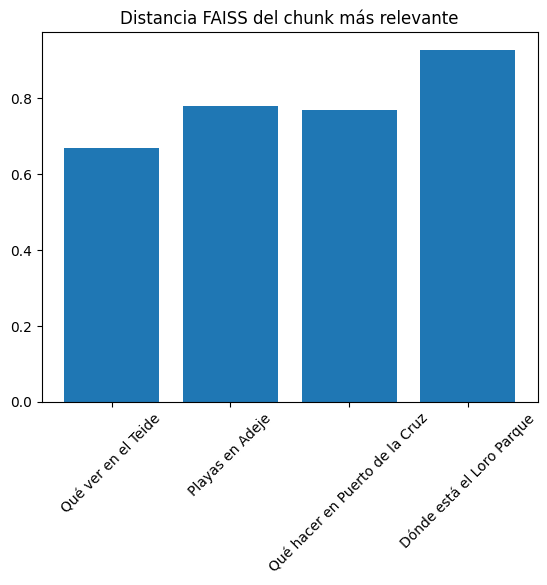

In [12]:
queries = [
    "Qué ver en el Teide",
    "Playas en Adeje",
    "Qué hacer en Puerto de la Cruz",
    "Dónde está el Loro Parque",
]

distances = []

for q in queries:
    r = retrieve(q, rag["chunks"], rag["index"], rag["metadata"], k=1)
    distances.append(r[0]["distance"])

plt.bar(range(len(queries)), distances)
plt.xticks(range(len(queries)), queries, rotation=45)
plt.title("Distancia FAISS del chunk más relevante")
plt.show()


## Análisis crítico del sistema

### Fortalezas
- RAG robusto con FAISS y embeddings OpenAI.
- Citas automáticas que mejoran la trazabilidad.
- Function calling real con manejo de errores.
- Memoria conversacional estable.
- Interfaz Streamlit intuitiva.

### Limitaciones
- Chunking basado en texto plano (no semántico).
- No se usa reranking.
- No se detectan contradicciones entre chunks.
- El modelo puede inventar detalles si el contexto es pobre.


Este notebook demuestra un asistente turístico completo basado en LLMs comerciales,
con RAG, memoria, function calling y análisis crítico. El sistema es reproducible,
modular y extensible, cumpliendo los requisitos de la entrega final.

***Otro notebook de test***
